# =========================================================
# AIM
# =========================================================

Developed an end-to-end Customer Intelligence System using classification, ensemble learning (Random Forest, XGBoost), and clustering techniques (K-Means, DBSCAN) to predict customer churn and generate actionable customer segmentation insights.

# **IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

# **LOAD DATASET**

In [2]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **EDA**

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.drop_duplicates(inplace = True)

In [9]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(
df['TotalCharges'],
errors='coerce'
)

In [10]:
df['TotalCharges'].fillna(
df['TotalCharges'].median(),
inplace=True
)

/tmp/ipykernel_9607/471836800.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


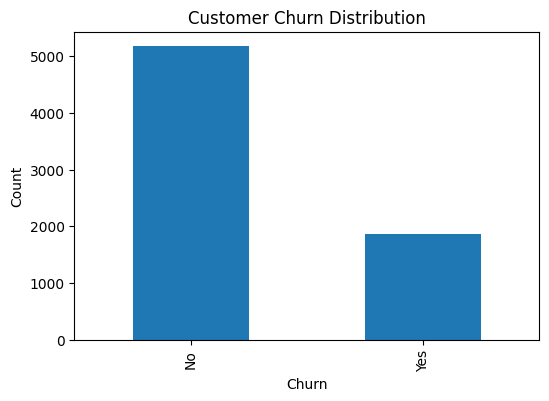

In [11]:
# TARGET VARIABLE DISTRIBUTION
plt.figure(figsize=(6,4))

df['Churn'].value_counts().plot(kind='bar')

plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Customer Churn Distribution")

plt.show()


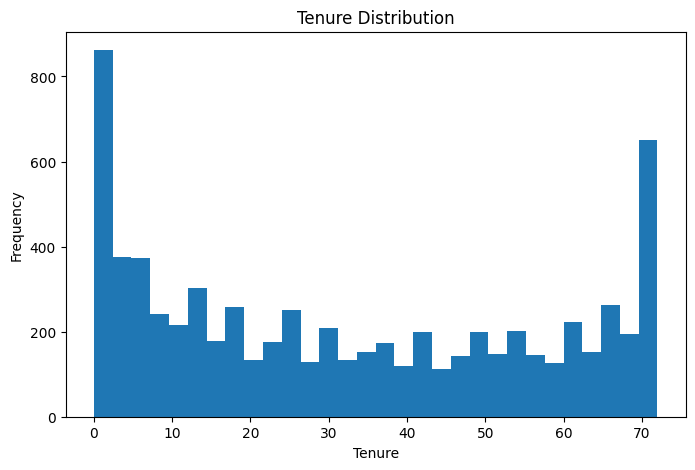

In [12]:
# TENURE DISTRIBUTION
plt.figure(figsize=(8,5))

plt.hist(df['tenure'], bins=30)

plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.title("Tenure Distribution")

plt.show()

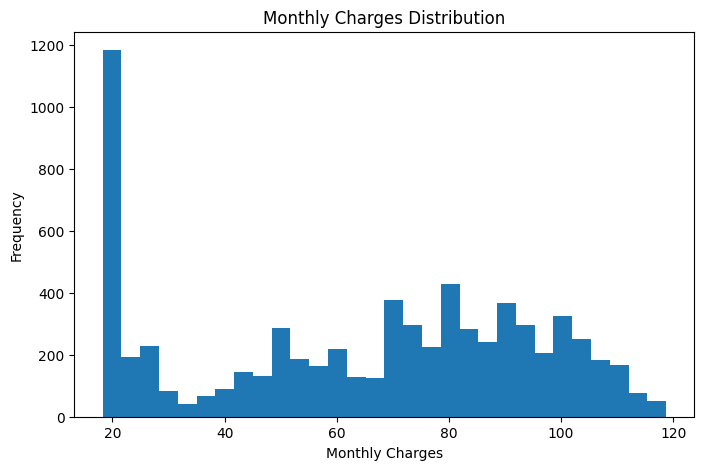

In [13]:
# MONTHLY CHARGES DISTRIBUTION
plt.figure(figsize=(8,5))

plt.hist(df['MonthlyCharges'], bins=30)

plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.title("Monthly Charges Distribution")

plt.show()

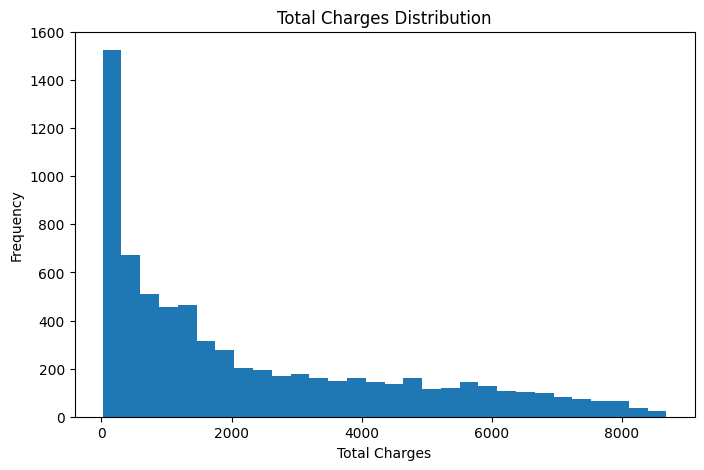

In [14]:
# TOTAL CHARGES DISTRIBUTION

plt.figure(figsize=(8,5))

plt.hist(df['TotalCharges'], bins=30)

plt.xlabel("Total Charges")
plt.ylabel("Frequency")
plt.title("Total Charges Distribution")

plt.show()

/tmp/ipykernel_9607/75297404.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


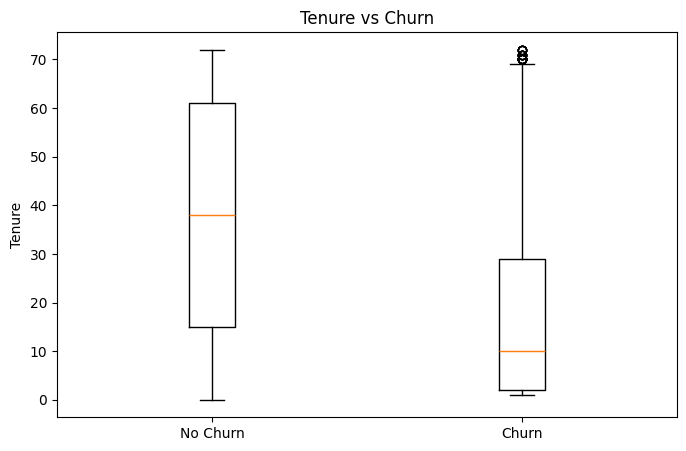

In [15]:
# CHURN VS TENURE
plt.figure(figsize=(8,5))

plt.boxplot(
[
df[df['Churn']=='No']['tenure'],
df[df['Churn']=='Yes']['tenure']
],
labels=['No Churn', 'Churn']
)

plt.ylabel("Tenure")
plt.title("Tenure vs Churn")

plt.show()

/tmp/ipykernel_9607/1339330288.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


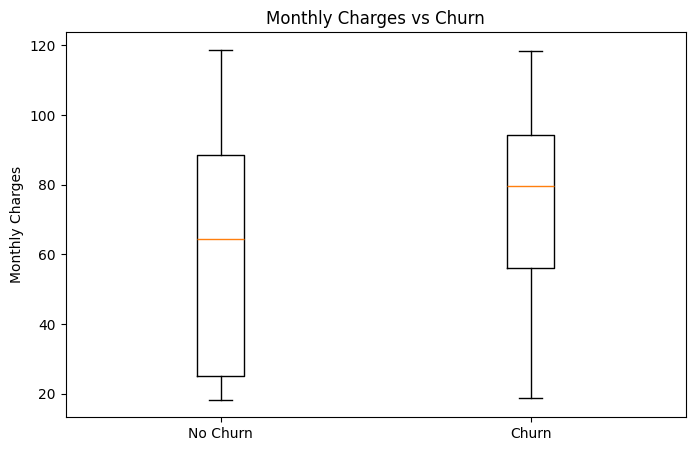

In [16]:
# CHURN VS MONTHLY CHARGES

plt.figure(figsize=(8,5))

plt.boxplot(
[
df[df['Churn']=='No']['MonthlyCharges'],
df[df['Churn']=='Yes']['MonthlyCharges']
],
labels=['No Churn', 'Churn']
)

plt.ylabel("Monthly Charges")
plt.title("Monthly Charges vs Churn")

plt.show()

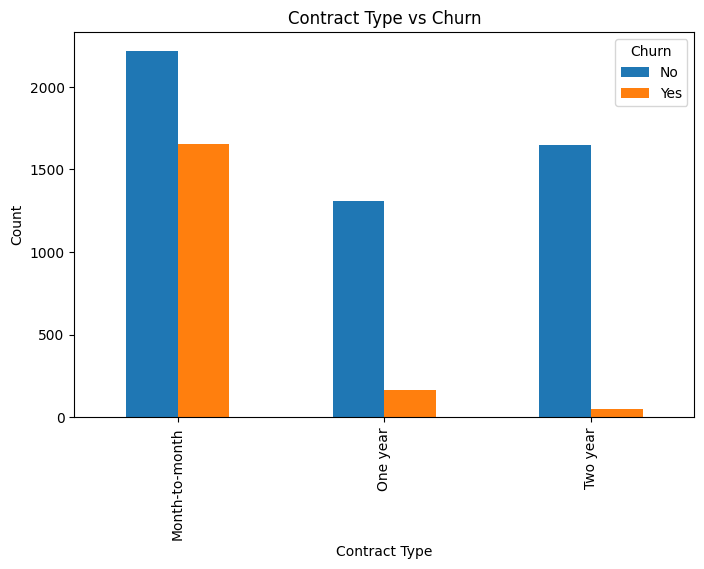

In [17]:
# CONTRACT TYPE VS CHURN

contract_churn = pd.crosstab(
df['Contract'],
df['Churn']
)

contract_churn.plot(
kind='bar',
figsize=(8,5)
)

plt.xlabel("Contract Type")
plt.ylabel("Count")
plt.title("Contract Type vs Churn")

plt.show()

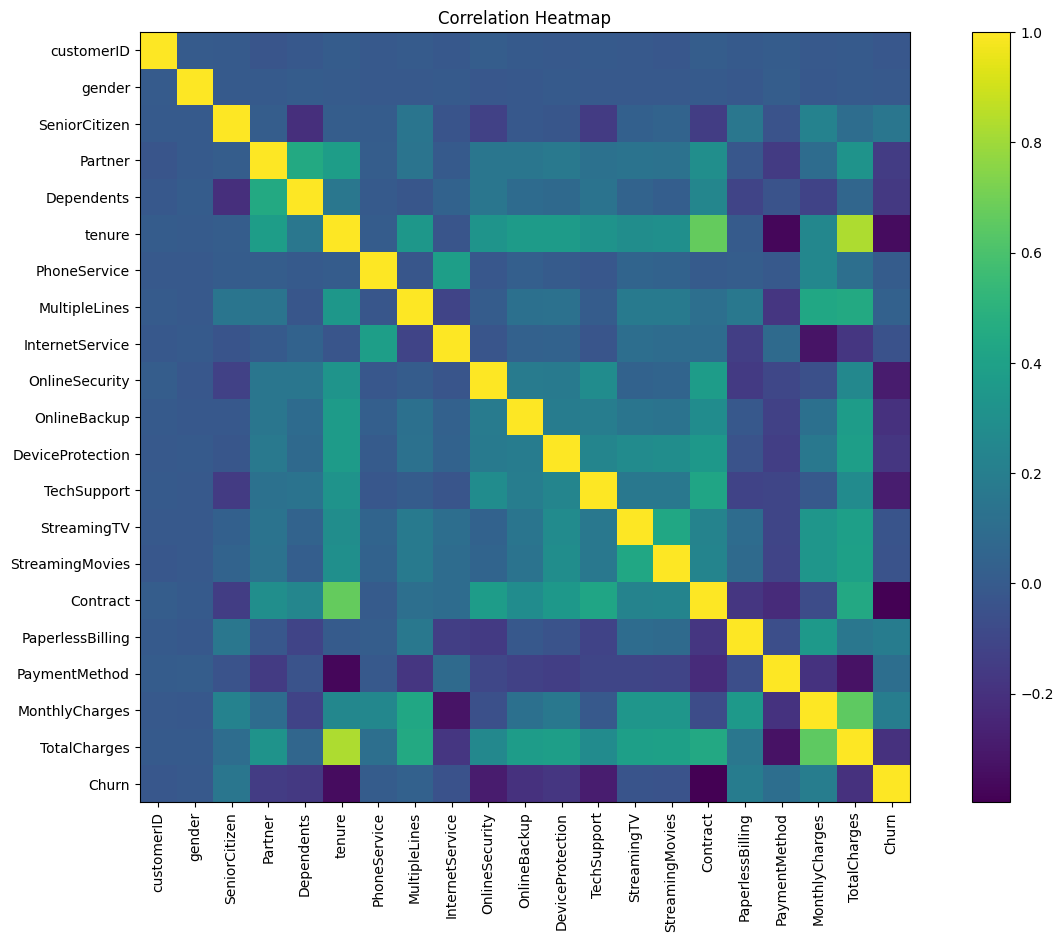

In [20]:
#  CORRELATION HEATMAP

corr = df.corr()

plt.figure(figsize=(16,10))

plt.imshow(corr)

plt.colorbar()

plt.xticks(
range(len(corr.columns)),
corr.columns,
rotation=90
)

plt.yticks(
range(len(corr.columns)),
corr.columns
)

plt.title("Correlation Heatmap")

plt.show()

# **DATA PREPROCESSING**

In [ ]:
# LABEL ENCODING

le = LabelEncoder()

for col in df.columns:

  if df[col].dtype == 'object':

     df[col] = le.fit_transform(df[col])


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,1,2,29.85,29.85,0
1,3962,1,0,0,0,34,1,0,0,2,...,2,0,0,0,1,0,3,56.95,1889.50,0
2,2564,1,0,0,0,2,1,0,0,2,...,0,0,0,0,0,1,3,53.85,108.15,1
3,5535,1,0,0,0,45,0,1,0,2,...,2,2,0,0,1,0,0,42.30,1840.75,0
4,6511,0,0,0,0,2,1,0,1,0,...,0,0,0,0,0,1,2,70.70,151.65,1


In [21]:
X = df.drop('Churn', axis=1)

y = df['Churn']

# **TRAIN TEST SPLIT**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify = y, random_state=42)

# **FEATURE SCALING**

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# HANDLE IMBALANCED DATA USING SMOTE

In [24]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
X_train_scaled,
y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_resampled).value_counts())

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64


# **CLASSIFICATION**



---



---





# **LOGISTIC REGRESSION**

In [25]:
lr = LogisticRegression()

lr.fit(
X_train_resampled,
y_train_resampled
)

y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:")

print(accuracy_score(y_test,y_pred_lr))

print("\nClassification Report:\n")

print(
classification_report(y_test,y_pred_lr))

Logistic Regression Accuracy:
0.7395315826827538

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



# **RANDOM FOREST**

In [26]:
rf = RandomForestClassifier(
n_estimators=300,
max_depth=10,
random_state=42
)

rf.fit(X_train_resampled,y_train_resampled)

y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Accuracy:")

print(accuracy_score(y_test,y_pred_rf))

print("\nClassification Report:\n")

print(classification_report(y_test,y_pred_rf))



Random Forest Accuracy:
0.7707594038325053

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.79      0.84      1035
           1       0.55      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.77      0.78      1409



# **XGBOOST**

In [27]:
xgb = XGBClassifier(
n_estimators=300,
learning_rate=0.05,
max_depth=5,
subsample=0.8,
colsample_bytree=0.8,
random_state=42
)

xgb.fit(X_train_resampled,y_train_resampled)

y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost Accuracy:")

print(accuracy_score(y_test,y_pred_xgb))

print("\nClassification Report:\n")

print(classification_report(y_test,y_pred_xgb))

XGBoost Accuracy:
0.7835344215755855

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1035
           1       0.58      0.64      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.79      1409



# **FEATURE IMPORTANCE**

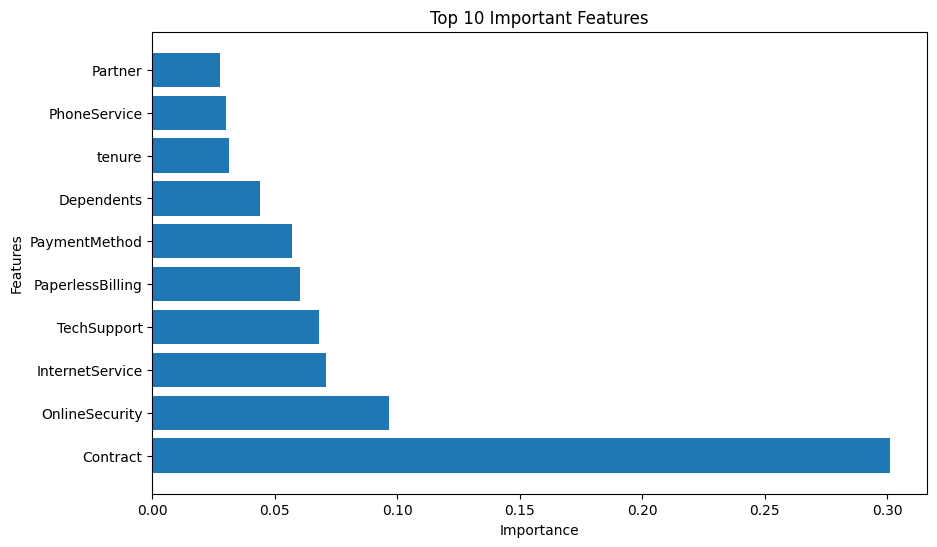

In [28]:
importance = pd.DataFrame({

'Feature': X.columns,
'Importance': xgb.feature_importances_

})

importance = importance.sort_values(by='Importance',ascending=False)

plt.figure(figsize=(10,6))

plt.barh(importance['Feature'][:10],importance['Importance'][:10])

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features")

plt.show()

# **CLUSTERING**

---



---



# **SELECT FEATURES FOR CLUSTERING** :
We selected `tenure`, `MonthlyCharges`, and `TotalCharges` because they are the most meaningful continuous features representing customer loyalty and spending behavior, which makes clustering more accurate and interpretable.


In [29]:
cluster_data = df[
[
'tenure',
'MonthlyCharges',
'TotalCharges'
]
]

In [30]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

# **ELBOW METHOD**

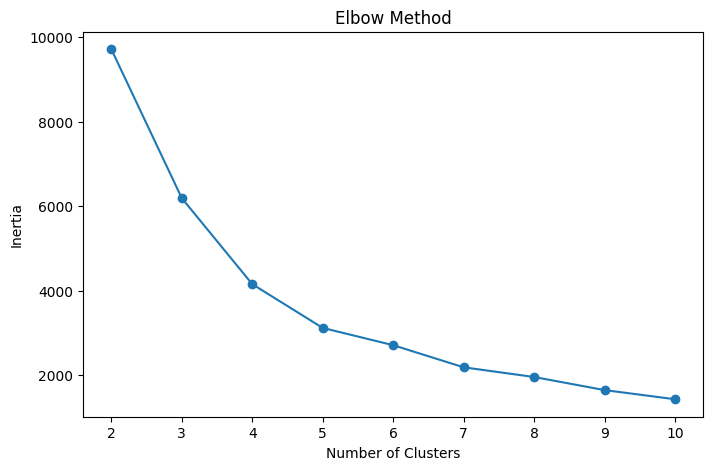

In [31]:
inertia = []

K = range(2,11)

for k in K:
  kmeans = KMeans(
    n_clusters=k,
    random_state=42
)

  kmeans.fit(cluster_scaled)

  inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K,inertia,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# **TRAIN KMEANS MODEL**

In [40]:
best_k = 4

kmeans = KMeans(
n_clusters=best_k,
random_state=42
)

clusters = kmeans.fit_predict(cluster_scaled)

df['KMeans_Cluster'] = clusters

print(df[['KMeans_Cluster']].head())

   KMeans_Cluster
0               2
1               0
2               2
3               0
4               3


In [41]:
score = silhouette_score(cluster_scaled,clusters)

print("Silhouette Score:")
print(score)

Silhouette Score:
0.4719670885081896


In [42]:
print(df['KMeans_Cluster'].value_counts())

KMeans_Cluster
3    2276
1    1904
2    1704
0    1159
Name: count, dtype: int64


# **DBSCAN CLUSTERING**

In [47]:
dbscan = DBSCAN(eps=1.5,min_samples=12)

db_clusters = dbscan.fit_predict(cluster_scaled)

df['DBSCAN_Cluster'] = db_clusters

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
0    7043
Name: count, dtype: int64


# **PCA DIMENSIONALITY REDUCTION**

In [36]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(cluster_scaled)

print(pca_features[:5])

[[-1.94954913 -0.08313009]
 [-0.20373016 -0.23535884]
 [-1.51584722  0.5220901 ]
 [-0.20056462 -0.89171597]
 [-1.23093729  0.96466738]]


# **PCA SCATTERPLOT**

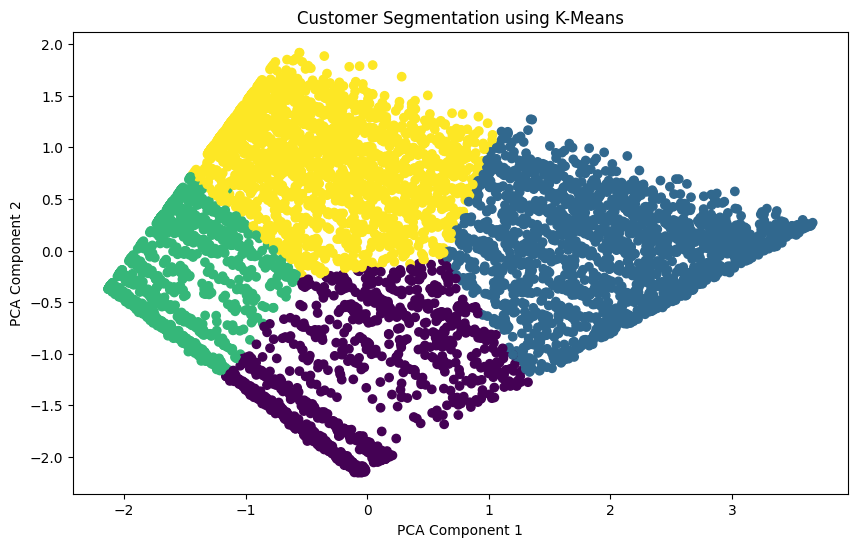

In [37]:
plt.figure(figsize=(10,6))

plt.scatter(
pca_features[:,0],
pca_features[:,1],
c=clusters
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using K-Means")

plt.show()

# **CLUSTER-WISE ANALYSIS**

In [38]:
cluster_analysis = df.groupby(
'KMeans_Cluster'
)[
[
'tenure',
'MonthlyCharges',
'TotalCharges'
]
].mean()

print(cluster_analysis)


                   tenure  MonthlyCharges  TotalCharges
KMeans_Cluster                                         
0               53.585850       34.920147   1836.581320
1               59.530987       93.306224   5548.653887
2               10.228873       31.769131    308.956397
3               15.424868       80.779657   1253.007239


In [39]:
dbscan_analysis = df.groupby(
'DBSCAN_Cluster'
)[
[
'tenure',
'MonthlyCharges',
'TotalCharges'
]
].mean()

print(dbscan_analysis)

                   tenure  MonthlyCharges  TotalCharges
DBSCAN_Cluster                                         
0               32.371149       64.761692   2281.916928


# =========================================================
# FINAL OBSERVATION & CONCLUSION
# =========================================================

"The project successfully predicted customer churn using ensemble learning models and achieved effective customer segmentation using K-Means and DBSCAN. XGBoost delivered the best classification performance, while clustering and PCA visualization revealed meaningful customer behavior patterns and well-separated customer groups. The system provided actionable insights for customer retention and business decision-making.